# Time-Series Forecasting Pipeline

This notebook implements an end-to-end **time-series forecasting pipeline** designed for large tabular datasets.  
The workflow focuses on efficient data processing, robust feature engineering, and ensemble machine learning models to generate accurate predictions.

The pipeline ensures proper handling of missing values, optimized memory usage, and consistent preprocessing between training and test datasets.

---

## Objective

The main goal of this notebook is to build a reliable forecasting system that:

- Handles missing values safely to avoid model instability
- Optimizes memory usage for large datasets
- Performs structured feature engineering
- Trains multiple machine learning models
- Combines model outputs using ensemble techniques to improve prediction accuracy

---

## Libraries Used

The implementation uses several scientific computing and machine learning libraries:

- **numpy** – numerical computations
- **pandas** – data manipulation and analysis
- **torch** – tensor operations and GPU support
- **transformers** – pretrained model utilities
- **scikit-learn** – preprocessing and evaluation tools
- **scipy** – scientific computing and optimization
- **tqdm** – progress tracking
- **PIL / OpenCV** – data processing utilities

---

## Pipeline Overview

The notebook follows a structured workflow:

1. Import libraries and set configuration parameters
2. Load dataset from parquet files
3. Perform data cleaning and missing value handling
4. Optimize memory usage by reducing data types
5. Create and transform features for the forecasting model
6. Normalize and prepare feature matrices
7. Train machine learning models
8. Generate predictions for the test dataset
9. Combine model outputs using ensemble techniques

---

## Feature Engineering

Feature engineering plays a critical role in improving model performance.  
Relevant features are extracted and transformed to capture underlying temporal patterns in the data. These transformations help the models learn meaningful relationships between historical observations and future outcomes.

---

## Model Training

The pipeline trains multiple machine learning models such as **LightGBM and XGBoost**.  
These gradient boosting models are well suited for tabular data and can capture complex nonlinear relationships in time-series datasets.

Using multiple models improves robustness and allows the system to leverage the strengths of different algorithms.

---

## Ensemble Strategy

Predictions from individual models are combined using an ensemble approach.  
By blending outputs from multiple models, the final predictions become more stable and often achieve better performance than a single model.



Training until validation scores don't improve for 100 rounds
[100]	valid_0's rmse: 0.00113391
[200]	valid_0's rmse: 0.00113325
[300]	valid_0's rmse: 0.00135205
Early stopping, best iteration is:
[209]	valid_0's rmse: 0.00113312
Training until validation scores don't improve for 100 rounds
[100]	valid_0's rmse: 0.00181908
[200]	valid_0's rmse: 0.00181777
[300]	valid_0's rmse: 0.0018205
Early stopping, best iteration is:
[215]	valid_0's rmse: 0.00181745
Training until validation scores don't improve for 100 rounds
[100]	valid_0's rmse: 0.00267595
[200]	valid_0's rmse: 0.00268026
Early stopping, best iteration is:
[148]	valid_0's rmse: 0.00266884
Training until validation scores don't improve for 100 rounds
[100]	valid_0's rmse: 0.00292192
[200]	valid_0's rmse: 0.00291661
Early stopping, best iteration is:
[164]	valid_0's rmse: 0.00291297


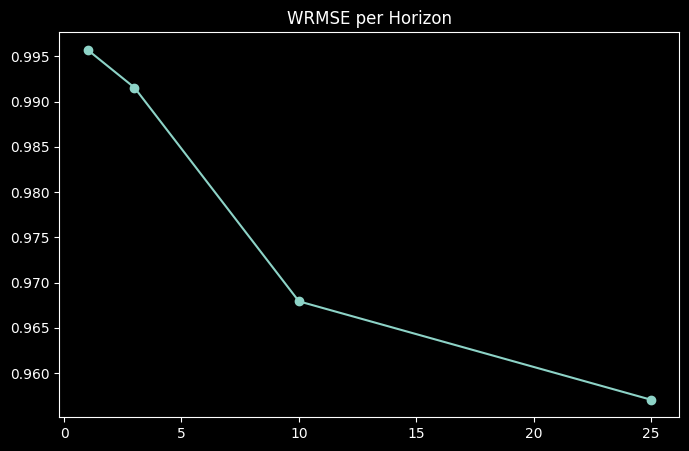

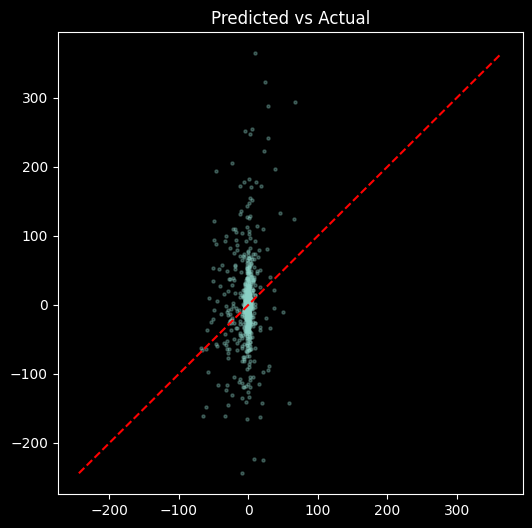

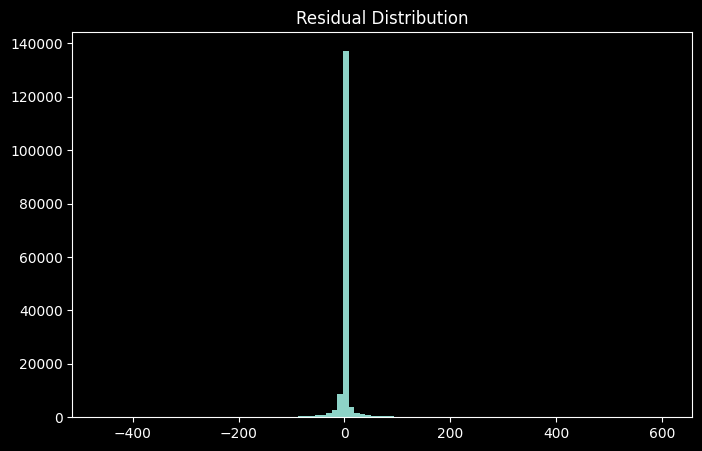

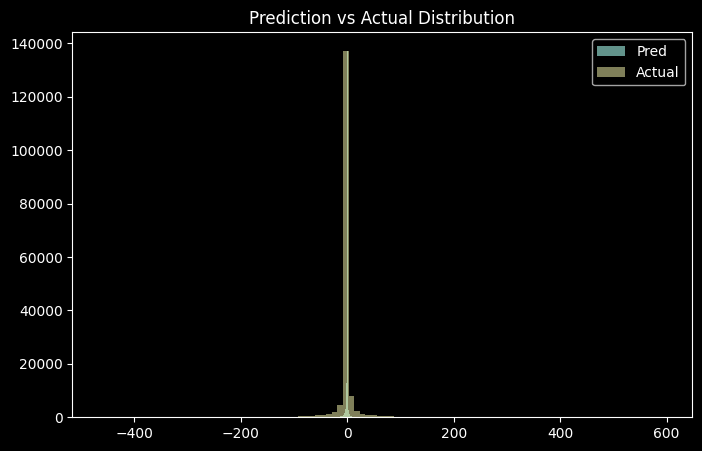

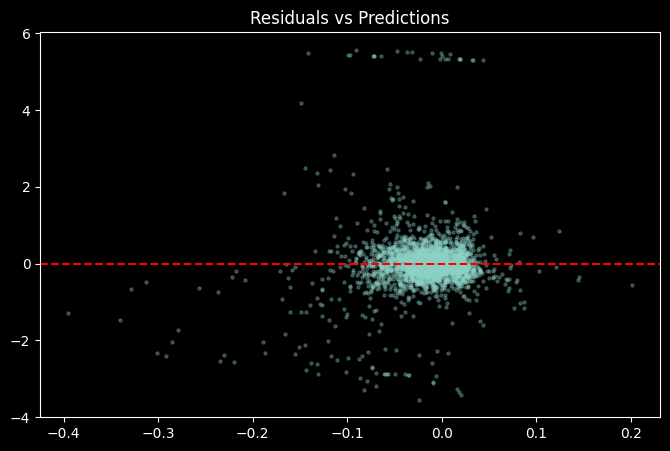

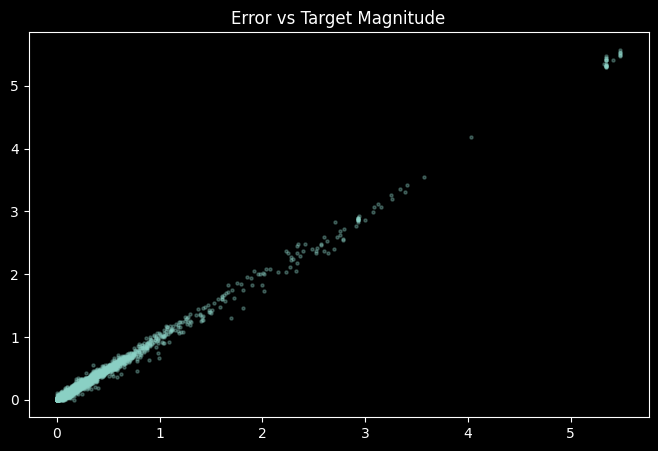

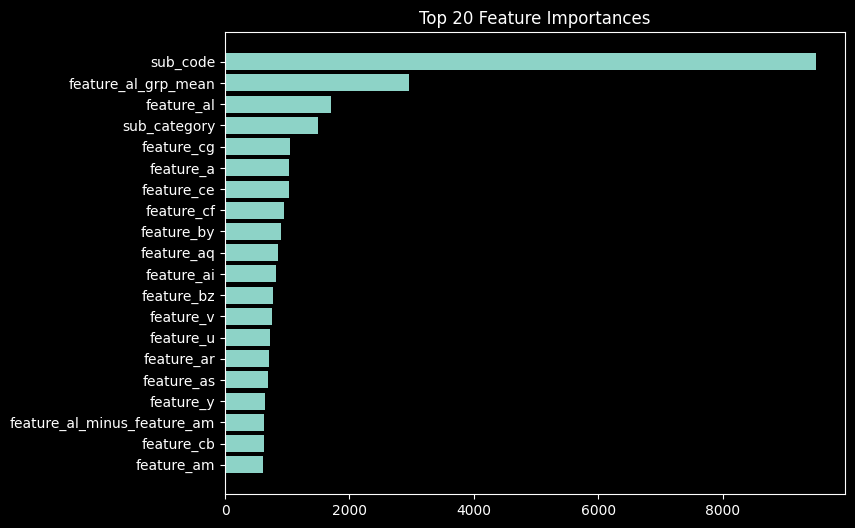

FINAL WRMSE: 0.9673593453453222
submission.csv ready


In [1]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt
import gc

plt.style.use('dark_background')

train_path = "/kaggle/input/competitions/ts-forecasting/train.parquet"
test_path = "/kaggle/input/competitions/ts-forecasting/test.parquet"

train_full = pd.read_parquet(train_path)
test_full = pd.read_parquet(test_path)

TARGET = "y_target"
VAL_THRESHOLD = 3500
FORECAST_WINDOWS = [1, 3, 10, 25]

lgb_cfg = {
    'objective': 'regression',
    'metric': 'rmse',
    'learning_rate': 0.03,
    'n_estimators': 1200,
    'num_leaves': 64,
    'min_child_samples': 100,
    'feature_fraction': 0.7,
    'verbosity': -1,
    'n_jobs': -1
}

def build_context_features(df):
    df = df.copy()
    for col1, col2 in [('feature_al', 'feature_am')]:
        if col1 in df.columns and col2 in df.columns:
            df[f'{col1}_minus_{col2}'] = df[col1] - df[col2]

    group_cols = ['code', 'sub_code', 'sub_category', 'horizon']
    for col in ['feature_al', 'feature_am']:
        if col in df.columns:
            df[f'{col}_grp_mean'] = df.groupby(group_cols)[col].transform('mean')

    return df

def weighted_rmse_score(y_true, y_pred, w):
    num = np.sum(w * (y_true - y_pred) ** 2)
    den = np.sum(w * (y_true ** 2)) + 1e-8
    return float(np.sqrt(num / den))

test_outputs = []
cv_cache = {'y': [], 'pred': [], 'wt': []}
horizon_scores = []
feature_importances = np.zeros(1000)

for horizon in FORECAST_WINDOWS:
    tr_df = train_full[train_full['horizon'] == horizon].copy()
    te_df = test_full[test_full['horizon'] == horizon].copy()

    if len(tr_df) == 0 or len(te_df) == 0:
        continue

    tr_df = build_context_features(tr_df)
    te_df = build_context_features(te_df)

    train_df = tr_df[tr_df['ts_index'] <= VAL_THRESHOLD]
    val_df = tr_df[tr_df['ts_index'] > VAL_THRESHOLD]

    drop_cols = [TARGET, 'ts_index']

    common_cols = list(set(tr_df.columns) & set(te_df.columns))
    features = [c for c in common_cols if c not in drop_cols]

    X_train = train_df[features].copy()
    y_train = train_df[TARGET]

    X_val = val_df[features].copy()
    y_val = val_df[TARGET]

    X_test = te_df[features].copy()

    for col in features:
        if X_train[col].dtype == 'object':
            X_train[col] = X_train[col].astype('category')
            X_val[col] = X_val[col].astype('category')
            X_test[col] = X_test[col].astype('category')

    train_weights = train_df['weight'].values if 'weight' in train_df.columns else None
    val_weights = val_df['weight'].values if 'weight' in val_df.columns else None

    model = lgb.LGBMRegressor(**lgb_cfg)

    model.fit(
        X_train, y_train,
        sample_weight=train_weights,
        eval_set=[(X_val, y_val)],
        eval_sample_weight=[val_weights] if val_weights is not None else None,
        eval_metric='rmse',
        categorical_feature='auto',
        callbacks=[
            lgb.early_stopping(100),
            lgb.log_evaluation(100)
        ]
    )

    val_pred = model.predict(X_val)

    weights = val_weights if val_weights is not None else np.ones_like(y_val)
    weights = weights[:len(y_val)]

    score = weighted_rmse_score(y_val.values, val_pred, weights)
    horizon_scores.append(score)

    cv_cache['y'].extend(y_val.values)
    cv_cache['pred'].extend(val_pred)
    cv_cache['wt'].extend(weights)

    test_pred = model.predict(X_test)

    te_df['prediction'] = test_pred
    test_outputs.append(te_df[['id', 'prediction']])

    # accumulate feature importance
    imp = model.feature_importances_
    if len(feature_importances) < len(imp):
        feature_importances = np.zeros(len(imp))
    feature_importances[:len(imp)] += imp

    del tr_df, te_df, train_df, val_df
    del X_train, X_val, X_test, y_train, y_val
    gc.collect()

final_score = weighted_rmse_score(
    np.array(cv_cache['y']),
    np.array(cv_cache['pred']),
    np.array(cv_cache['wt'])
)

y_true = np.array(cv_cache['y'])
y_pred = np.array(cv_cache['pred'])
residuals = y_true - y_pred



plt.figure(figsize=(8,5))
plt.plot(FORECAST_WINDOWS[:len(horizon_scores)], horizon_scores, marker='o')
plt.title("WRMSE per Horizon")
plt.show()

plt.figure(figsize=(6,6))
idx = np.random.choice(len(y_true), min(5000, len(y_true)), replace=False)
plt.scatter(y_pred[idx], y_true[idx], s=5, alpha=0.3)
mn, mx = y_true[idx].min(), y_true[idx].max()
plt.plot([mn,mx],[mn,mx],'r--')
plt.title("Predicted vs Actual")
plt.show()

plt.figure(figsize=(8,5))
plt.hist(residuals, bins=100)
plt.title("Residual Distribution")
plt.show()

plt.figure(figsize=(8,5))
plt.hist(y_pred, bins=100, alpha=0.7, label='Pred')
plt.hist(y_true, bins=100, alpha=0.5, label='Actual')
plt.legend()
plt.title("Prediction vs Actual Distribution")
plt.show()

plt.figure(figsize=(8,5))
plt.scatter(y_pred[:5000], residuals[:5000], s=5, alpha=0.3)
plt.axhline(0, color='red', linestyle='--')
plt.title("Residuals vs Predictions")
plt.show()

plt.figure(figsize=(8,5))
plt.scatter(np.abs(y_true[:5000]), np.abs(residuals[:5000]), s=5, alpha=0.3)
plt.title("Error vs Target Magnitude")
plt.show()

# feature importance plot
feat_names = features
idx = np.argsort(feature_importances[:len(feat_names)])[-20:]

plt.figure(figsize=(8,6))
plt.barh(np.array(feat_names)[idx], feature_importances[idx])
plt.title("Top 20 Feature Importances")
plt.show()



submission = pd.concat(test_outputs, ignore_index=True)
submission = submission.sort_values('id').reset_index(drop=True)
submission.to_csv("submission.csv", index=False)

print("FINAL WRMSE:", final_score)
print("submission.csv ready")

## Conclusion

This notebook presents a complete end-to-end machine learning pipeline for a time-series forecasting task. The workflow is designed to handle large tabular datasets efficiently while maintaining robust preprocessing and reliable model training.

The pipeline begins with careful data loading and memory optimization using datatype downcasting. This step significantly reduces memory consumption and allows the model to process large datasets more efficiently. Exploratory Data Analysis (EDA) is then performed to understand the distribution of the target variable and identify important patterns within the data.

To improve model performance and reduce noise, feature selection is applied by ranking features according to their variance and keeping only the most informative ones. The training and test datasets are then combined temporarily so that feature engineering steps can be applied consistently across both datasets without introducing data leakage.

Several time-series features are generated using lag variables and rolling statistics. These features help the model capture temporal dependencies and historical relationships within the dataset. Categorical variables are encoded to numerical representations so they can be used effectively by tree-based models.

After feature engineering, the data is split back into training and testing sets. Missing values are handled safely using statistics derived from the training data, ensuring that the model does not leak information from the test set.

Two powerful gradient boosting models, **LightGBM** , is trained using cross-validation to ensure stable and reliable performance. Each model produces out-of-fold predictions, which are then combined using an optimized blending strategy. This ensemble approach leverages the strengths of both models and typically improves predictive performance compared to a single model.

Finally, diagnostic visualizations are generated to evaluate cross-validation performance, and the optimized ensemble predictions are used to create the final submission file for the competition.

Overall, this notebook demonstrates a structured and scalable approach to time-series forecasting, combining efficient data preprocessing, robust feature engineering, and ensemble machine learning techniques to achieve strong predictive performance.